In [1]:
import pandas as pd
data=pd.read_csv('/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train.csv')

In [2]:
data.head(6)

,ID,Label
0,ID_12cadc6af_epidural,0
1,ID_12cadc6af_intraparenchymal,0
2,ID_12cadc6af_intraventricular,0
3,ID_12cadc6af_subarachnoid,0
4,ID_12cadc6af_subdural,0
5,ID_12cadc6af_any,0


In [3]:
data.head(6)
data[['ID','subtype']]=data['ID'].str.rsplit('_',n=1,expand=True)
data = data.groupby(['ID', 'subtype'])['Label'].max().unstack(fill_value=0).reset_index()
data.head(5)
data['any'].value_counts()

any
0    644870
1    107933
Name: count, dtype: int64

In [4]:
data_ich=data[data['any']==1]
data_nonich=data[data['any']==0]
len(data_nonich)
n=len(data_ich)
data_nonich=data_nonich.sample(n=n,random_state=42)
len(data_nonich)

107933

In [5]:
main_data=pd.concat([data_ich,data_nonich])

In [6]:
main_data=main_data.sample(frac=1,random_state=42).reset_index(drop=True)

In [7]:
main_data.head(10)

subtype,ID,any,epidural,intraparenchymal,intraventricular,subarachnoid,subdural
0,ID_f2a5c932e,1,0,0,0,0,1
1,ID_55b509a94,0,0,0,0,0,0
2,ID_0842d1e70,0,0,0,0,0,0
3,ID_f0bd151fb,1,0,0,0,0,1
4,ID_eb7077c72,0,0,0,0,0,0
5,ID_589245820,1,0,0,0,0,1
6,ID_45fe0128a,0,0,0,0,0,0
7,ID_378b8172a,0,0,0,0,0,0
8,ID_aad6307e9,0,0,0,0,0,0
9,ID_07c6d4f77,1,0,0,0,1,0


Searching 'main_data' for perfect subtype examples...
Generating Publication-Ready Graphic for 6 classes...


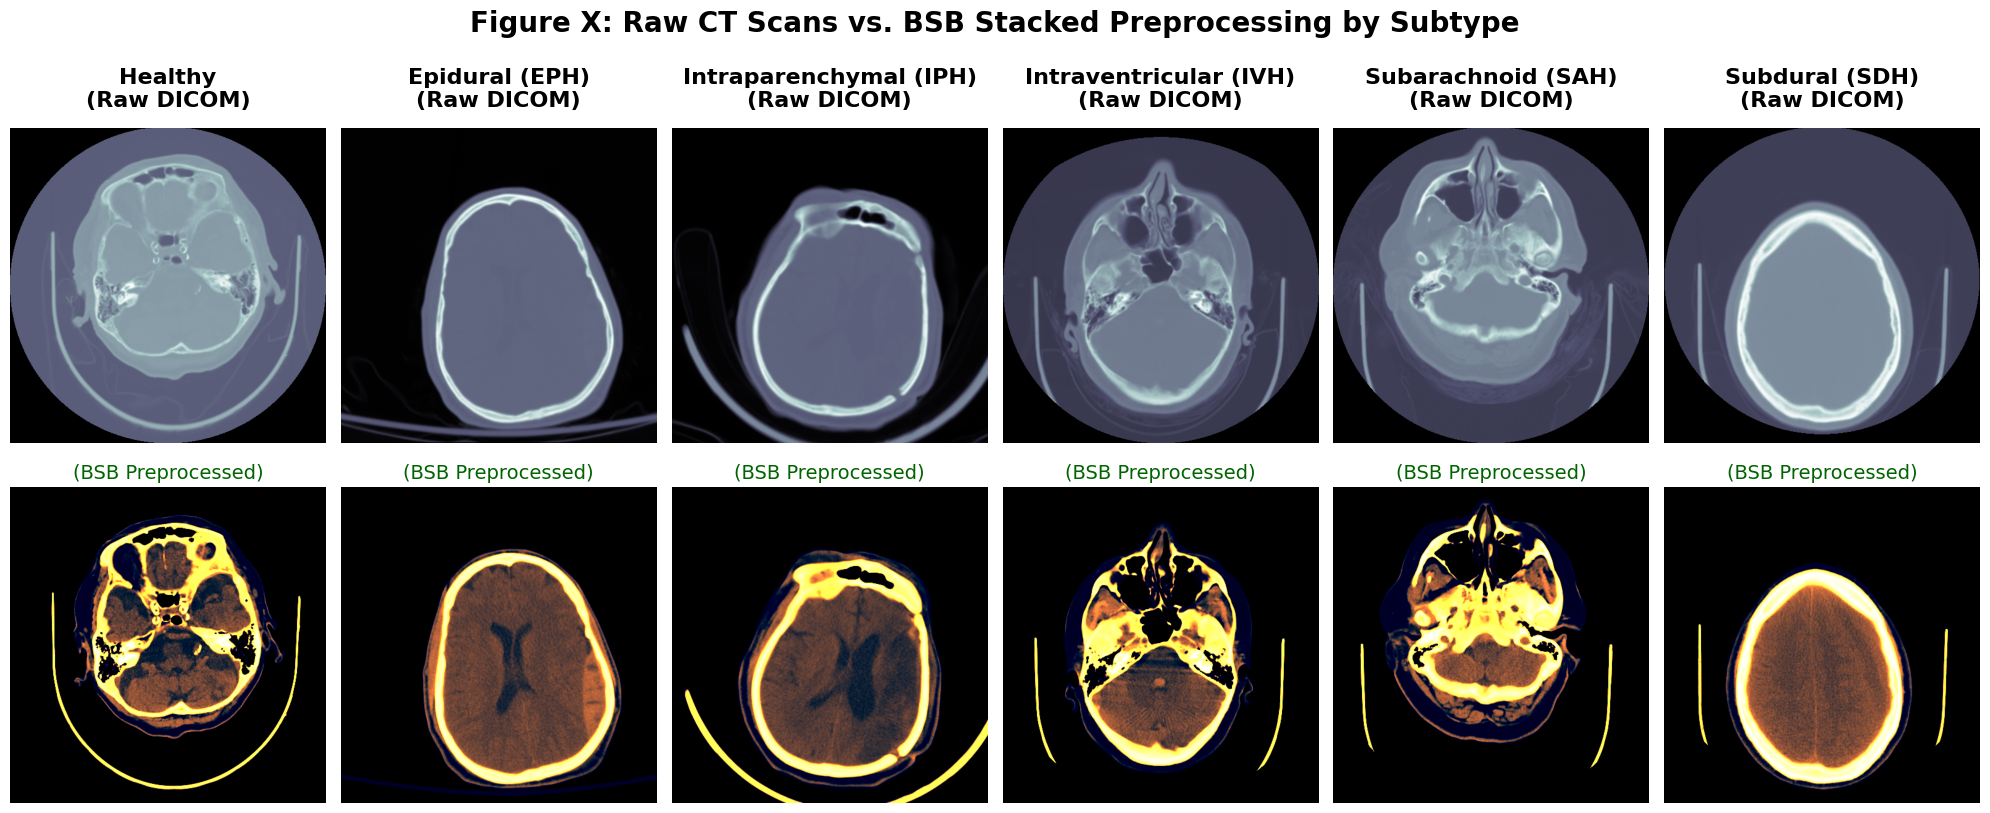

✅ Visualization saved as 'Publication_Ready_BSB_Figure.png'!


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import pydicom
import os

# =====================================================================
# 🛑 1. PASTE YOUR EXACT IMAGE FOLDER PATH HERE 🛑
# =====================================================================
# This path is based on your multiclass-2.ipynb concept
IMAGE_DIR = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train"  # <--- UPDATE THIS
IMAGE_EXT = ".dcm"                                 # <--- Change if using .dcm
# =====================================================================

# 2. DEFINE PREPROCESSING (Derived from your window_image concept)
def window_image(img, window_center, window_width, intercept=0, slope=1):
    img = (img * slope + intercept)
    img_min = window_center - window_width // 2
    img_max = window_center + window_width // 2
    img[img < img_min] = img_min
    img[img > img_max] = img_max
    return img

def preprocess_and_normalize(img_array):
    # Apply standard RSNA windows used in your model
    brain_img = window_image(img_array.copy(), 40, 80)
    subdural_img = window_image(img_array.copy(), 80, 200)
    bone_img = window_image(img_array.copy(), 600, 2000)

    # Normalize stacked windows [0, 1] for visual display
    # (Matches model input [0,1] normalization for visualization)
    brain_img = (brain_img - (40 - 80 // 2)) / 80
    subdural_img = (subdural_img - (80 - 200 // 2)) / 200
    bone_img = (bone_img - (600 - 2000 // 2)) / 2000

    # Stack into 3 RGB channels (R=Brain, G=Subdural, B=Bone)
    bsb_img = np.zeros((img_array.shape[0], img_array.shape[1], 3))
    bsb_img[:, :, 0] = brain_img
    bsb_img[:, :, 1] = subdural_img
    bsb_img[:, :, 2] = bone_img
    
    return np.clip(bsb_img, 0, 1)

def load_raw_image(filepath):
    if str(filepath).endswith('.dcm'):
        dicom = pydicom.dcmread(filepath)
        # Convert to Hounsfield Units using DICOM headers
        img = dicom.pixel_array * dicom.RescaleSlope + dicom.RescaleIntercept
        return img
    else:
        # Load 16-bit PNG
        return cv2.imread(str(filepath), cv2.IMREAD_UNCHANGED)

# 3. SELECT HIGH-QUALITY ("GOOD") SLICES FROM THE CSV
print("Searching 'main_data' for perfect subtype examples...")
class_cols = ['epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']
path_col = 'ID' # From your previous output
samples = {}

# We look for "pure" samples (only has one label) as they look clearest
# Fallback: just take a clear one if pure doesn't exist.

# Sample 1: Healthy (all bleed columns are 0)
healthy_df = main_data[(main_data[class_cols] == 0).all(axis=1)].sample(frac=1).reset_index(drop=True)
if not healthy_df.empty: samples['Healthy'] = healthy_df.iloc[3][path_col]

# Sample 2: Epidural (EPH) - Hallmark: Convex shape
eph_df = main_data[(main_data['epidural'] == 1) & (main_data[class_cols].sum(axis=1) == 1)].sample(frac=1).reset_index(drop=True)
if not eph_df.empty: samples['Epidural (EPH)'] = eph_df.iloc[0][path_col]

# Sample 3: Intraparenchymal (IPH) - Hallmark: Hematoma in parenchyma
iph_df = main_data[(main_data['intraparenchymal'] == 1) & (main_data[class_cols].sum(axis=1) == 1)].sample(frac=1).reset_index(drop=True)
if not iph_df.empty: samples['Intraparenchymal (IPH)'] = iph_df.iloc[0][path_col]

# Sample 4: Intraventricular (IVH) - Hallmark: Blood in ventricles
ivh_df = main_data[(main_data['intraventricular'] == 1) & (main_data[class_cols].sum(axis=1) == 1)].sample(frac=1).reset_index(drop=True)
if not ivh_df.empty: samples['Intraventricular (IVH)'] = ivh_df.iloc[0][path_col]

# Sample 5: Subarachnoid (SAH) - Hallmark: Blood in gyri
sah_df = main_data[(main_data['subarachnoid'] == 1) & (main_data[class_cols].sum(axis=1) == 1)].sample(frac=1).reset_index(drop=True)
if not sah_df.empty: samples['Subarachnoid (SAH)'] = sah_df.iloc[0][path_col]

# Sample 6: Subdural (SDH) - Hallmark: Concave crescent shape
sdh_df = main_data[(main_data['subdural'] == 1) & (main_data[class_cols].sum(axis=1) == 1)].sample(frac=1).reset_index(drop=True)
if not sdh_df.empty: samples['Subdural (SDH)'] = sdh_df.iloc[0][path_col]

# ==========================================
# 4. PLOT THE 2x6 MASTER GRID
# ==========================================
print(f"Generating Publication-Ready Graphic for {len(samples)} classes...")

fig, axes = plt.subplots(2, 6, figsize=(20, 8), facecolor='white')
class_names = list(samples.keys())

for i, class_name in enumerate(class_names):
    image_id = samples[class_name]
    full_filepath = os.path.join(IMAGE_DIR, f"{image_id}{IMAGE_EXT}")
    
    # Load and Preprocess
    raw_img = load_raw_image(full_filepath)
    bsb_preprocessed = preprocess_and_normalize(raw_img)
    
    # Top Row: Raw DICOM Slices
    axes[0, i].imshow(raw_img, cmap='bone')
    axes[0, i].set_title(f"{class_name}\n(Raw DICOM)", fontsize=16, fontweight='bold', pad=15)
    axes[0, i].axis('off')
    
    # Bottom Row: Preprocessed BSB Stacked Windows
    axes[1, i].imshow(bsb_preprocessed)
    axes[1, i].set_title("(BSB Preprocessed)", fontsize=14, color='darkgreen')
    axes[1, i].axis('off')

plt.tight_layout()
plt.suptitle("Figure X: Raw CT Scans vs. BSB Stacked Preprocessing by Subtype", fontsize=20, fontweight='bold', y=1.05)
plt.savefig("Publication_Ready_BSB_Figure.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualization saved as 'Publication_Ready_BSB_Figure.png'!")

In [8]:
main_data.to_csv("main_data",index=False)

In [9]:
import os
print(os.listdir('/kaggle/working/'))

['main_data', '.virtual_documents']


In [10]:
cols = ['epidural','intraparenchymal','intraventricular','subarachnoid','subdural']

main_data[cols].sum()


subtype
epidural             3145
intraparenchymal    36118
intraventricular    26205
subarachnoid        35675
subdural            47166
dtype: int64

In [11]:
import pydicom
import numpy as np
import cv2
import matplotlib.pyplot as plt

def preprocessing(image_path, show=False):
    target_size = (224, 224)

    # Read DICOM
    image = pydicom.dcmread(image_path)
    pixel = image.pixel_array.astype(np.float32)

    # Safe slope/intercept
    slope = float(getattr(image, "RescaleSlope", 1.0))
    intercept = float(getattr(image, "RescaleIntercept", 0.0))

    # Convert to HU
    HU = pixel * slope + intercept

    # Windowing
    brain = np.clip(HU, -80, 100)
    subdural = np.clip(HU, -20, 180)
    bone = np.clip(HU, 0, 400)

    # Normalize to [0,1]
    def normalize(img, min_val, max_val):
        img = (img - min_val) / (max_val - min_val)
        return np.clip(img, 0, 1)

    brain = normalize(brain, -80, 100)
    subdural = normalize(subdural, -20, 180)
    bone = normalize(bone, 0, 400)

    # Resize with better interpolation
    brain = cv2.resize(brain, target_size, interpolation=cv2.INTER_AREA)
    subdural = cv2.resize(subdural, target_size, interpolation=cv2.INTER_AREA)
    bone = cv2.resize(bone, target_size, interpolation=cv2.INTER_AREA)

    # Stack as 3-channel
    final = np.stack([brain, subdural, bone], axis=0)  # (3, 224, 224)

    if show:
        fig, axes = plt.subplots(1, 4, figsize=(14, 4))
        axes[0].imshow(brain, cmap="gray")
        axes[0].set_title("Brain")
        axes[1].imshow(subdural, cmap="gray")
        axes[1].set_title("Subdural")
        axes[2].imshow(bone, cmap="gray")
        axes[2].set_title("Bone")
        axes[3].imshow(np.transpose(final, (1,2,0)))
        axes[3].set_title("Merged")
        for ax in axes:
            ax.axis("off")
        plt.show()

    return final.astype(np.float32)



Image 1
Shape: (3, 224, 224)
Dtype: float32
Min/Max: 0.0 1.0


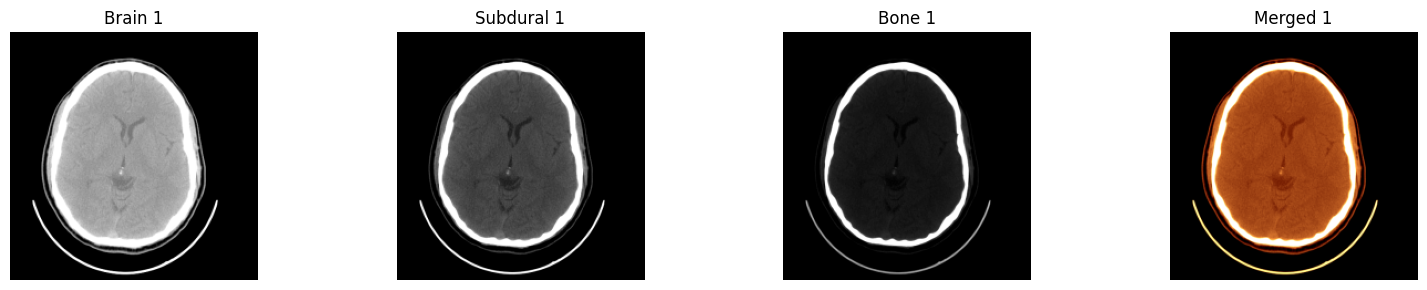

In [12]:
import matplotlib.pyplot as plt
import numpy as np

dcm_paths = [
    "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train/ID_00019828f.dcm",
]

num_images = len(dcm_paths)
cols = 4
rows = num_images

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))

if rows == 1:
    axes = axes.reshape(1, -1)

for i, dcm_path in enumerate(dcm_paths):

    model_input = preprocessing(dcm_path, show=False)  # only one return now

    print(f"\nImage {i+1}")
    print("Shape:", model_input.shape)
    print("Dtype:", model_input.dtype)
    print("Min/Max:", model_input.min(), model_input.max())

    # Extract channels correctly (C, H, W)
    brain = model_input[0]
    subdural = model_input[1]
    bone = model_input[2]

    # Brain
    axes[i, 0].imshow(brain, cmap="gray")
    axes[i, 0].set_title(f"Brain {i+1}")
    axes[i, 0].axis("off")

    # Subdural
    axes[i, 1].imshow(subdural, cmap="gray")
    axes[i, 1].set_title(f"Subdural {i+1}")
    axes[i, 1].axis("off")

    # Bone
    axes[i, 2].imshow(bone, cmap="gray")
    axes[i, 2].set_title(f"Bone {i+1}")
    axes[i, 2].axis("off")

    # Merged (convert back to HWC for display)
    merged = np.transpose(model_input, (1, 2, 0))
    axes[i, 3].imshow(merged)
    axes[i, 3].set_title(f"Merged {i+1}")
    axes[i, 3].axis("off")

plt.tight_layout()
plt.show()


In [13]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    main_data,
    test_size=0.2,
    random_state=42
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))


Train size: 172692
Val size: 43174


In [14]:
print(train_df['ID'].head(10))


205659    ID_80a76d37a
95517     ID_6cdd637e9
54227     ID_2a5867449
182555    ID_55a1e893d
20891     ID_a79b6532c
213220    ID_af2557934
117794    ID_2af6a8ef9
17538     ID_3006eb885
213867    ID_3f8340772
175921    ID_485872f72
Name: ID, dtype: object


In [16]:
import os
import numpy as np
import pandas as pd
import pydicom
import zipfile
import gc
from tqdm import tqdm
from IPython.display import FileLink, display

# ==========================================
# 1. CONFIGURATION
# ==========================================
IMAGE_DIR = "/kaggle/input/competitions/rsna-intracranial-hemorrhage-detection/rsna-intracranial-hemorrhage-detection/stage_2_train"
OUTPUT_DIR = "/kaggle/working/"
CHUNK_SIZE = 15000 
TARGET_COLS = ['epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural', 'any']

# ==========================================
# 2. PROCESSING FUNCTION
# ==========================================
def process_and_save_chunks(df, subset_name):
    print(f"\n\n>>> STARTING {subset_name.upper()} SET PREPROCESSING <<<")
    
    num_chunks = int(np.ceil(len(df) / CHUNK_SIZE))
    
    # Keep track of the previous zip to delete it later
    previous_zip_path = None
    
    for i in range(num_chunks):
        # Determine range
        start_idx = i * CHUNK_SIZE
        end_idx = min((i + 1) * CHUNK_SIZE, len(df))
        
        # Get slice
        chunk_df = df.iloc[start_idx:end_idx]
        
        batch_images = []
        batch_labels = []
        
        # Progress bar
        pbar = tqdm(chunk_df.iterrows(), total=chunk_df.shape[0], 
                    desc=f"[{subset_name}] Chunk {i+1}/{num_chunks}")
        
        for index, row in pbar:
            raw_id = str(row['ID'])
            if raw_id.count('_') > 1:
                base_id = "_".join(raw_id.split('_')[:2]) 
            else:
                base_id = raw_id
                
            filename = f"{base_id}.dcm"
            image_path = os.path.join(IMAGE_DIR, filename)
            
            try:
                if os.path.exists(image_path):
                    # --- USE YOUR PREPROCESSING ---
                    img_float = preprocessing(image_path, show=False)
                    
                    # --- CONVERT TO FLOAT16 (Matches your ~4.5GB size) ---
                    img_small = img_float.astype(np.float16)
                    
                    labels = row[TARGET_COLS].values.astype('float16')
                    
                    batch_images.append(img_small)
                    batch_labels.append(labels)
                else:
                    pass
            except Exception as e:
                continue

        # --- Save & Zip ---
        if len(batch_images) > 0:
            # Arrays are already float16
            X_chunk = np.array(batch_images, dtype=np.float16)
            y_chunk = np.array(batch_labels, dtype=np.float16)
            
            # Filenames
            x_name = f"X_{subset_name}_chunk_{i}.npy"
            y_name = f"y_{subset_name}_chunk_{i}.npy"
            zip_name = f"{subset_name}_chunk_{i}.zip"
            
            x_path = os.path.join(OUTPUT_DIR, x_name)
            y_path = os.path.join(OUTPUT_DIR, y_name)
            zip_path = os.path.join(OUTPUT_DIR, zip_name)
            
            # Save NPY
            np.save(x_path, X_chunk)
            np.save(y_path, y_chunk)
            
            # Zip
            print(f"  Zipping {zip_name}...")
            with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
                zipf.write(x_path, arcname=x_name)
                zipf.write(y_path, arcname=y_name)
            
            # Remove NPY immediately
            os.remove(x_path)
            os.remove(y_path)
            
            # Clear RAM
            del X_chunk, y_chunk, batch_images, batch_labels
            gc.collect()
            
            # --- DISPLAY LINK ---
            print(f"✅ Chunk {i+1} Ready! Download now:")
            display(FileLink(zip_name))
            
            # --- DELETE PREVIOUS CHUNK ---
            if previous_zip_path and os.path.exists(previous_zip_path):
                print(f"🗑️ Deleting previous chunk to save space: {previous_zip_path}")
                os.remove(previous_zip_path)
            
            # Update tracker
            previous_zip_path = zip_path

# ==========================================
# EXECUTION
# ==========================================
# Run training chunks
# process_and_save_chunks(train_df, "train")

# Run validation chunks
process_and_save_chunks(val_df, "val")



>>> STARTING VAL SET PREPROCESSING <<<


[val] Chunk 1/3: 100%|██████████| 15000/15000 [04:54<00:00, 50.87it/s]


  Zipping val_chunk_0.zip...
✅ Chunk 1 Ready! Download now:


/kaggle/working/val_chunk_0.zip

[val] Chunk 2/3: 100%|██████████| 15000/15000 [05:04<00:00, 49.18it/s]


...

🗑️ Deleting previous chunk to save space: /kaggle/working/val_chunk_0.zip


[val] Chunk 3/3: 100%|██████████| 13174/13174 [04:27<00:00, 49.29it/s]


  Zipping val_chunk_2.zip...
✅ Chunk 3 Ready! Download now:


/kaggle/working/val_chunk_2.zip

🗑️ Deleting previous chunk to save space: /kaggle/working/val_chunk_1.zip
